Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


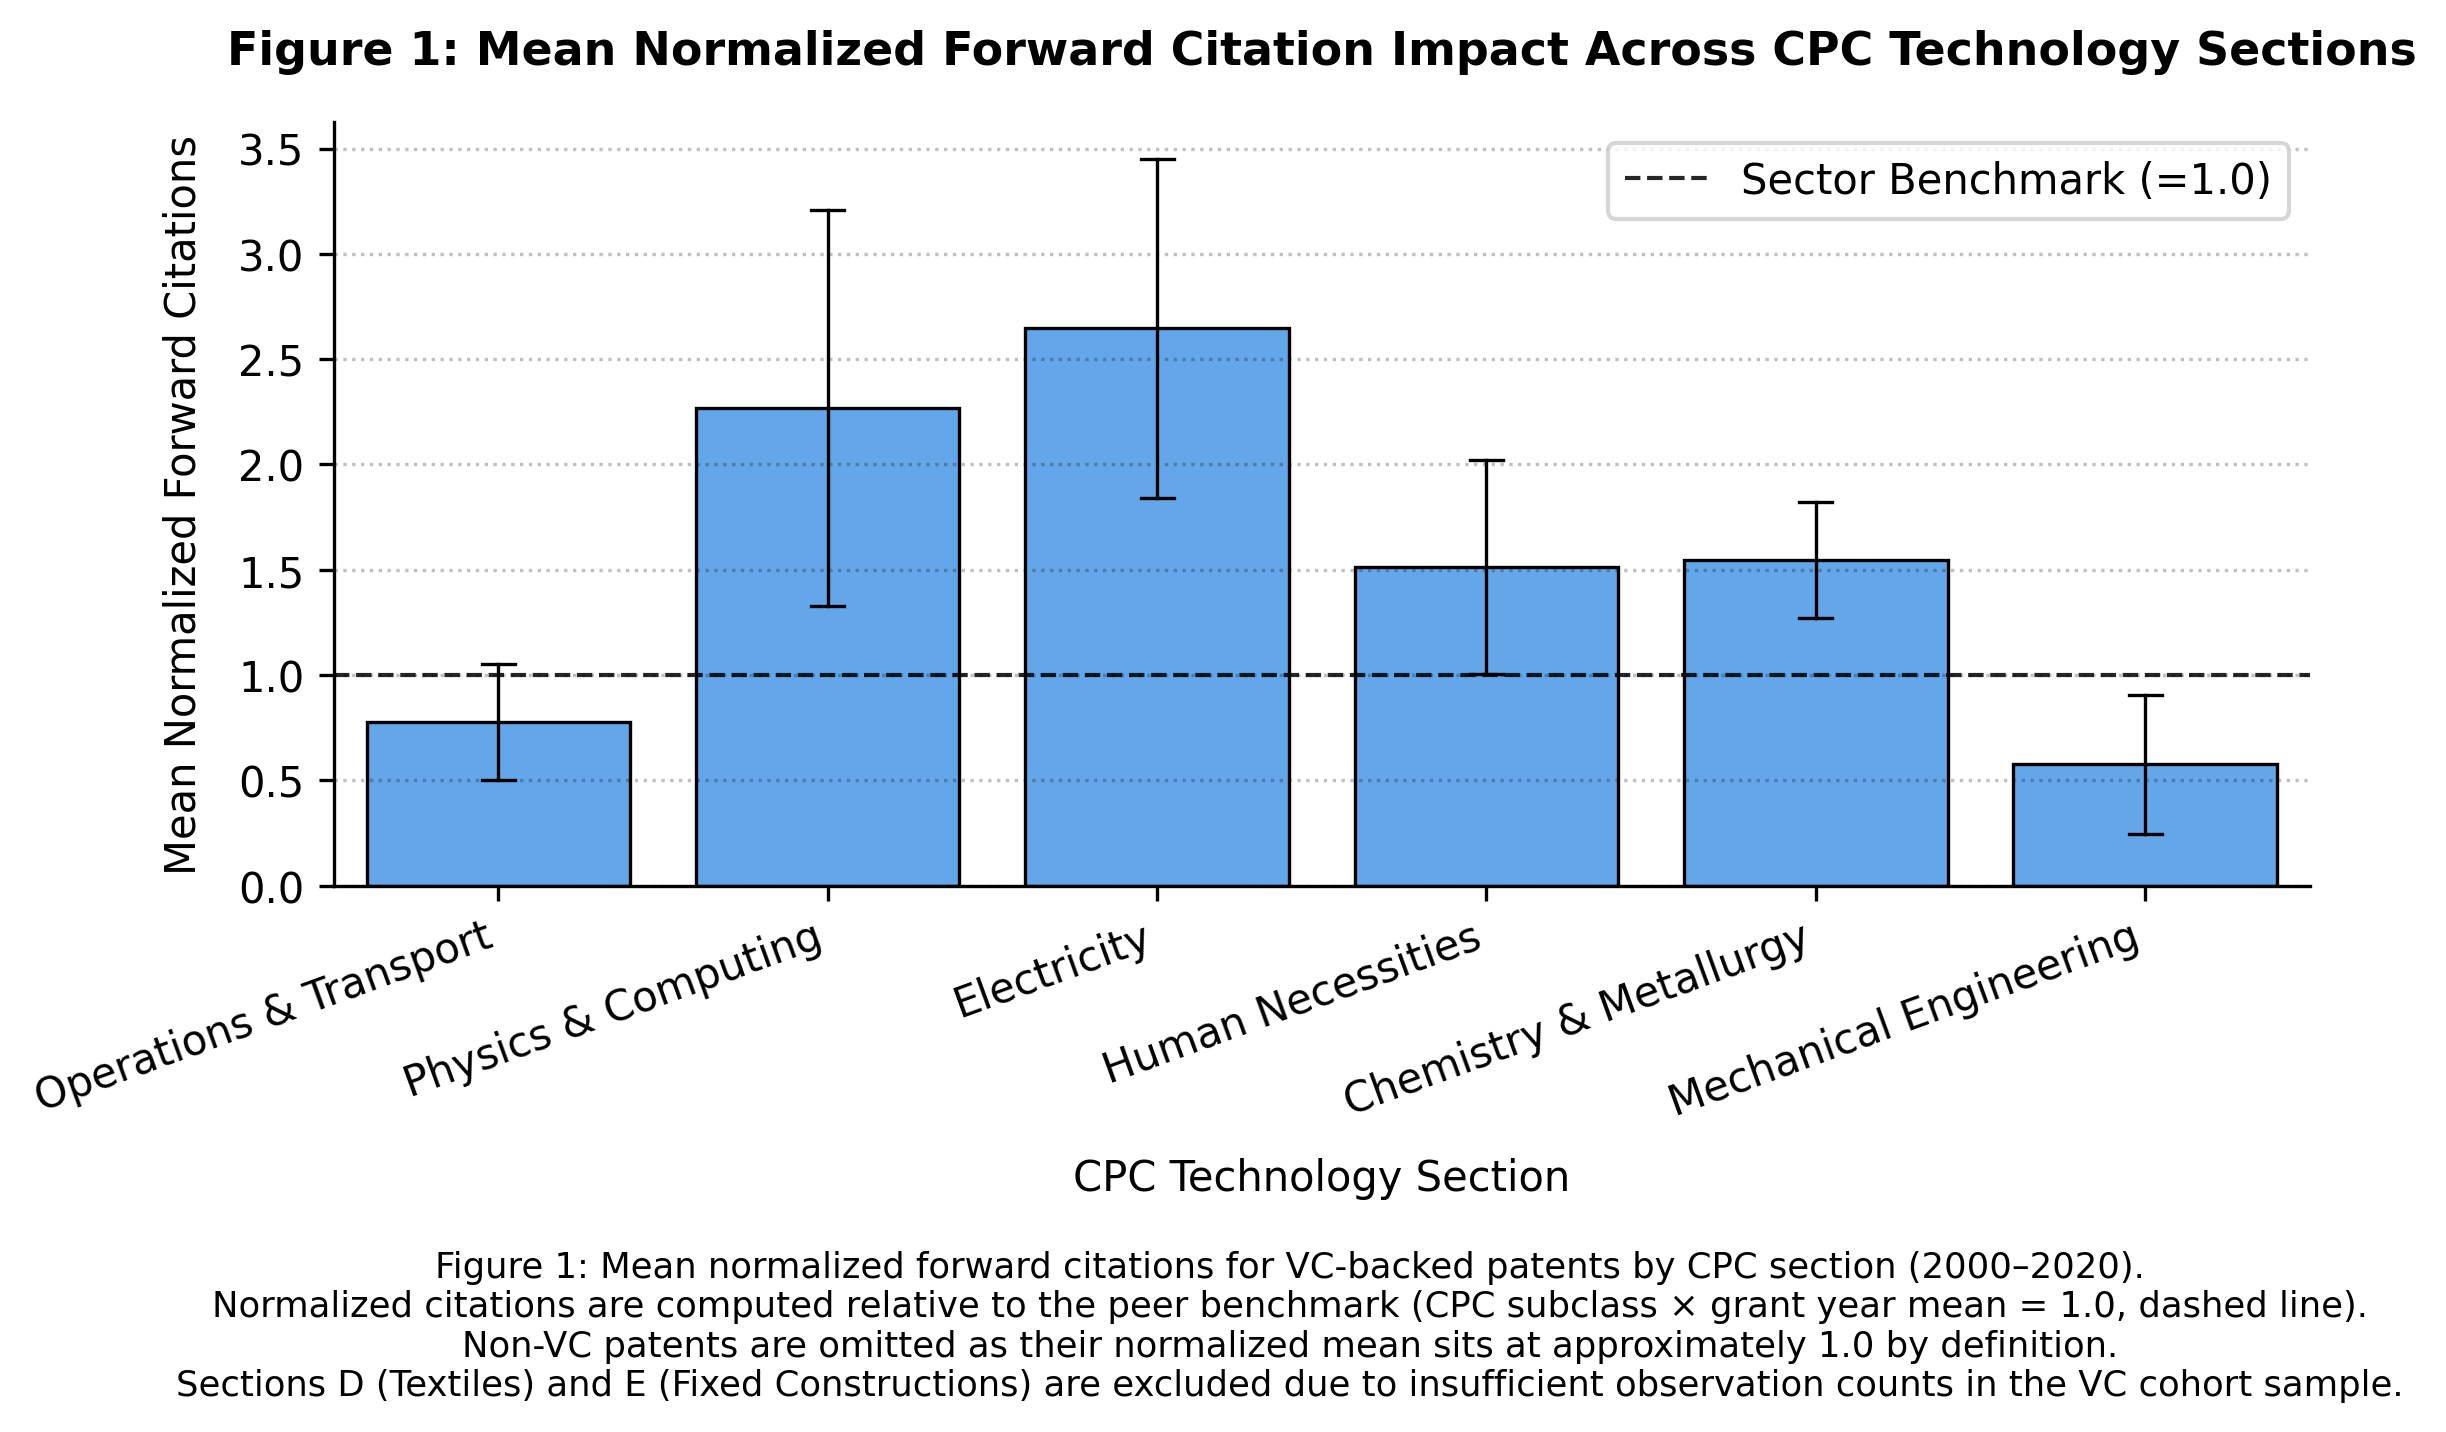

In [ ]:
import os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

#functions
def load_cpc_section_citations(parquet_file):
    con = duckdb.connect()
    df = con.execute(f"""
        SELECT
            CASE cpc_section
                WHEN 'A' THEN 'Human Necessities'
                WHEN 'B' THEN 'Operations & Transport'
                WHEN 'C' THEN 'Chemistry & Metallurgy'
                WHEN 'F' THEN 'Mechanical Engineering'
                WHEN 'G' THEN 'Physics & Computing'
                WHEN 'H' THEN 'Electricity'
            END AS cpc_section,
            normalized_forward_citations
        FROM '{parquet_file}'
        WHERE cpc_section IS NOT NULL
          AND cpc_section NOT IN ('UNKNOWN', 'D', 'E')
          AND vc_backed = 1
          AND normalized_forward_citations IS NOT NULL;
    """).df()
    return df

def generate_citation_barplot(df, output_path):
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': '#000000',
        'grid.color': '#000000',
        'grid.alpha': 0.25
    })

    fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=300)

    sns.barplot(
        data=df,
        x='cpc_section',
        y='normalized_forward_citations',
        color='#4da6ff',
        edgecolor='#000000',
        linewidth=0.8,
        errorbar='se',
        capsize=0.1,
        err_kws={'linewidth': 0.8, 'color': '#000000'},
        ax=ax
    )

    ax.axhline(1.0, color='#000000', linestyle='--', linewidth=1.0, alpha=0.85, label='Sector Benchmark (=1.0)')

    ax.set_title('Figure 1: Mean Normalized Forward Citation Impact Across CPC Technology Sections', fontsize=11, fontweight='bold', pad=14)
    ax.set_xlabel('CPC Technology Section', fontsize=10, labelpad=8)
    ax.set_ylabel('Mean Normalized Forward Citations', fontsize=10, labelpad=8)
    ax.grid(True, linestyle=':', axis='y')

    #labels
    plt.xticks(rotation=20, ha='right')

    ax.legend(frameon=True, loc='upper right')

    caption = (
        "Figure 1: Mean normalized forward citations for VC-backed patents by CPC section (2000–2020).\n"
        "Normalized citations are computed relative to the peer benchmark (CPC subclass × grant year mean = 1.0, dashed line).\n"
        "Non-VC patents are omitted as their normalized mean sits at approximately 1.0 by definition.\n"
        "Sections D (Textiles) and E (Fixed Constructions) are excluded due to insufficient observation counts in the VC cohort sample."
    )

    plt.subplots_adjust(bottom=0.35)
    fig.text(0.5, 0.00, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

#figure 1

#setup paths and load data
drive_mount_point = os.path.join(os.sep, "content", "drive")
drive.mount(drive_mount_point, force_remount=False)

drive_data_dir = os.path.join(drive_mount_point, "MyDrive", "data")
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

df_sec = load_cpc_section_citations(parquet_path)

fig1_path = os.path.join(drive_data_dir, "figure1_cpc_section_citations.png")
generate_citation_barplot(df_sec, fig1_path)